In [40]:
import confnotebook

In [41]:
from pathlib import Path

source = Path("../examples/test/full")

files = sorted(source.glob("*.pdf"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")

[0] 10
[1] 126164
[2] 14964427_Енисейская ТГК-13-БРАЗ
[3] 14976087_АвеларСолар Тех-БРАЗ-1
[4] 15120979_Форвард Энерго-БРАЗ-1
[5] 15235008_ОГК-2-БРАЗ-1
[6] 25
[7] 33
[8] 4
[9] 44
[10] 7-1
[11] АС ВНИИМ Менделеева Д.И. - БРАЗ на 31.12.24
[12] АС ВНИИМ Менделеева Д.И. - РУ на 31.12.24
[13] АС КРЕЗОЛ-САЗ на 31.08.25
[14] АС Охрана Металлург-САЗ на 31.12.25
[15] АС РУ- ВОСЬМОЙ ВЕТРОПАРК
[16] АС Фрейт Линк-БРАЗ на 30.09.25
[17] АСР СДД 2 кв.2024 (подп. к-а)
[18] Акт сверки взаимных расчетов №00000379931 от 30.04.2024
[19] Акт сверки №0000
[20] Акт сверки №MOW00-0087974   от 10.06.2024
[21] Акт сверки №ТРБП-000006 от 10.01.2024
[22] Браз-Юнигрин Пауэр
[23] ЕВР-НКАЗ
[24] Неформализованный_первичный_документ_23_ИИА_03_00342_от_31_03
[25] Неформализованный_первичный_документ_23_ИИА_03_02596_от_31_03
[26] Неформализованный_первичный_документ_23_ИИА_03_03623_от_31_03
[27] Неформализованный_первичный_документ_23_ИИА_06_01794_от_30_06
[28] ПР_АС КРЕЗОЛ-САЗ на 31.08.25
[29] ПР_АС Фрейт Линк-

In [42]:
IDX_FILE = 0

In [43]:
from vision_core.debug_image_observer import DebugImageObserver

file = files[IDX_FILE]
output_dir = f"../examples/output/{file.stem}"

debug_image_observer = DebugImageObserver(output_dir=output_dir)

In [44]:
from vision_core.loader.pdf_loader import PDFLoader

img = PDFLoader(pdf_bytes=file.read_bytes()).get_page_image(page_num=0, dpi=200)

In [45]:
from vision_core.config import PageOrientationPreprocessorConfig
from vision_core.detector.table_detector import TableDetector
from vision_core.ocr.paddle_ocr import PaddleOcrEngine
from vision_core.postprocessor.cell_text_filler import CellTextFiller
from vision_core.preprocessor.image_orientation import PageOrientationPreprocessor
from vision_core.preprocessor.image_preprocessor import ImagePreprocessor

cfg = PageOrientationPreprocessorConfig()
cfg.edge_scan_range_deg = 5.0  # максимальный угол для сканирования краев
cfg.edge_scan_step_deg = 0.5  # шаг между углами для сканирования краев
cfg.edge_scan_deviation_deg = 0.5  # максимальное отклонение между углами с разных краев
cfg.edge_scan_size = -1  # -1 = весь край 
cfg.edge_scan_depth = 0.5  # доля ширины/высоты для сканирования

image_preprocessor = ImagePreprocessor().process(img)
image_aligned, _ = PageOrientationPreprocessor(cfg).process(image_preprocessor)
tables = TableDetector().detect_tables(image_aligned)

ocr_results = PaddleOcrEngine().predict([image_aligned])
cell_text_filler = CellTextFiller(confidence_threshold=0.5)
cell_text_filler.fill_cells(tables, ocr_results[0])
filtered_ocr = cell_text_filler.exclude_table_text(ocr_results[0], tables)

2026-04-19 12:15:54.313 | DEBUG    | vision_core.preprocessor.image_orientation:process:40 - Ориентация страницы: 0° с точностью 0.8993
2026-04-19 12:15:54.424 | DEBUG    | vision_core.preprocessor.image_orientation:_detect_rotation:124 - edge rotations: [0.0, -0.0, 0.0, -0.5]°
2026-04-19 12:15:54.425 | DEBUG    | vision_core.preprocessor.image_orientation:_detect_rotation:133 - после фильтрации: [0.0, -0.0, 0.0, -0.5]°
2026-04-19 12:15:54.425 | DEBUG    | vision_core.preprocessor.image_orientation:_detect_rotation:140 - для усреднения используются: [0.0, -0.0, 0.0, -0.5]°
2026-04-19 12:15:54.426 | DEBUG    | vision_core.preprocessor.image_orientation:_detect_rotation:151 - average: -0.500°  deviation: 0.866°
2026-04-19 12:15:54.426 | DEBUG    | vision_core.preprocessor.image_orientation:_detect_rotation:156 - deviation too large -- no rotation
2026-04-19 12:15:54.427 | DEBUG    | vision_core.preprocessor.image_orientation:process:54 - Угол наклона страницы: 0.000°
2026-04-19 12:15:54.

1. удаление таблиц со страницы

[mask]   таблица удалена: bbox=(81,326,1601,819)
[mask] Таблиц удалено: 1


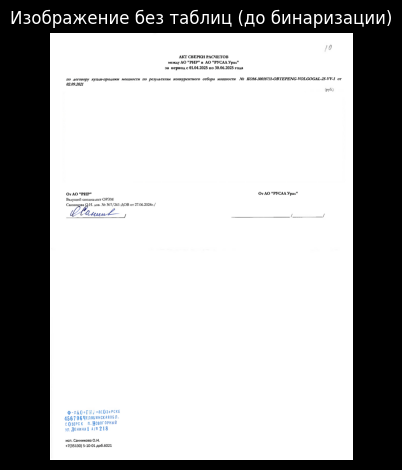

In [46]:
import matplotlib.pyplot as plt

image_clean = image_aligned.copy()
for tbl in tables:
    x1, y1 = int(tbl.bbox.x_min), int(tbl.bbox.y_min)
    x2, y2 = int(tbl.bbox.x_max), int(tbl.bbox.y_max)
    image_clean[y1:y2, x1:x2] = 255
    print(f"[mask]   таблица удалена: bbox=({x1},{y1},{x2},{y2})")
print(f"[mask] Таблиц удалено: {len(tables)}")

plt.imshow(image_clean)
plt.title("Изображение без таблиц (до бинаризации)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [47]:
import numpy as np

# считаем медиану высоты строк из распознанного текста

row_heights = []
for line in filtered_ocr:
    x1, y1, x2, y2 = line.bbox
    row_heights.append(y2 - y1)

median_row_height = np.median(row_heights)
print(f"Медиана высоты строк: {median_row_height:.2f} пикселей")

Медиана высоты строк: 29.00 пикселей


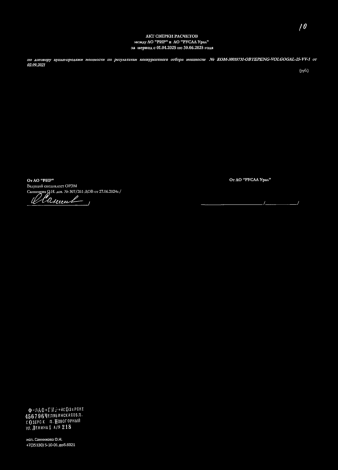

In [48]:
import cv2

# 2. Бинаризация очищенного изображения
gray = cv2.cvtColor(image_clean, cv2.COLOR_RGB2GRAY) if image_clean.ndim == 3 else image_clean.copy()
binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, blockSize=21, C=20)

plt.imshow(binary, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()


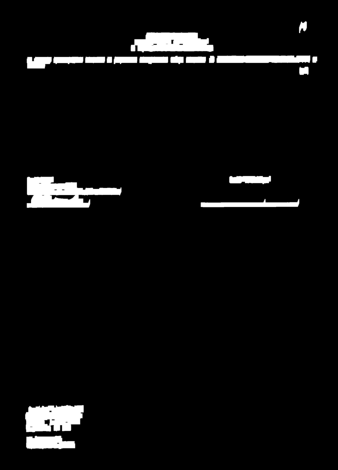

In [49]:
kw = max(10, int(median_row_height * 0.4))
kh = max(7,  int(median_row_height * 0.8))

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kw, kh))
dilated = cv2.dilate(binary, kernel, iterations=1)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 1))
eroded = cv2.erode(dilated, kernel, iterations=1)



plt.imshow(eroded, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

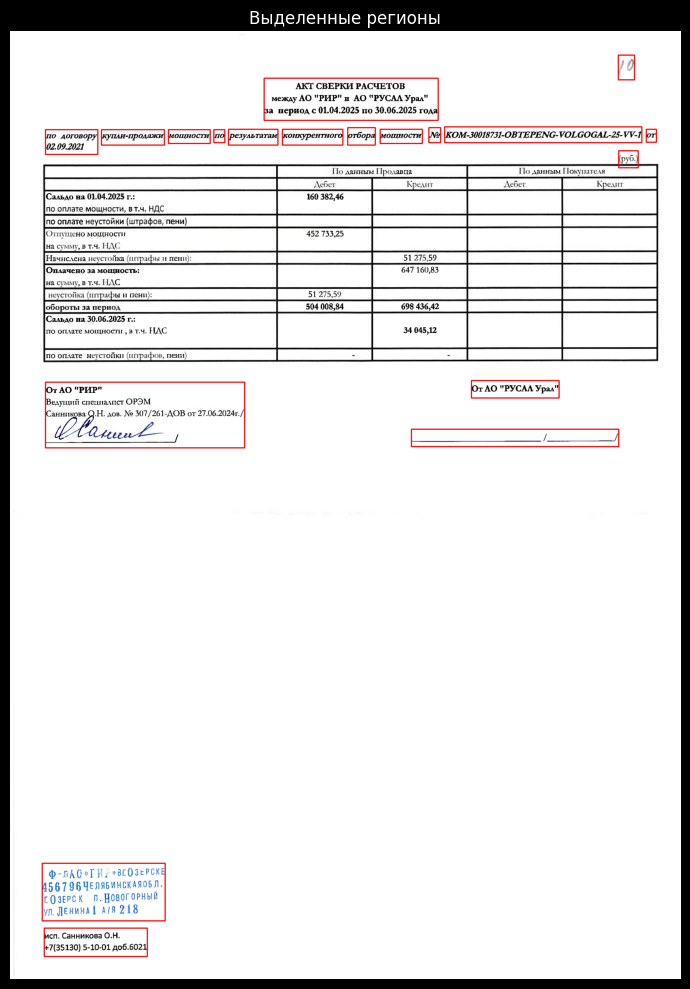

In [50]:
# 4. Контуры -> bounding boxes, без фильтрации
contours, _ = cv2.findContours(eroded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

debug_img = image_aligned.copy()
raw_regions = []
for c in contours:
    x, y, w, h = cv2.boundingRect(c)

    cv2.rectangle(debug_img, (x, y), (x + w, y + h), (255, 0, 0), 2)
    raw_regions.append((x, y, x + w, y + h))

raw_regions.sort(key=lambda b: (b[1], b[0]))

plt.figure(figsize=(10, 10))
plt.imshow(debug_img)
plt.title("Выделенные регионы")
plt.axis("off")
plt.tight_layout()
plt.show()

## Сущность Paragraph

In [51]:

from enum import Enum

from pydantic import BaseModel

from vision_core.entities.bbox import BBox


class ParagraphType(Enum):
    """
    Перечисление типов структурных элементов, обнаруженных на странице.
    """
    UNKNOWN = "Неизвестный тип"
    PAGE_HEADER = "Верхний колонтитул"  # Элементы в верхней части страницы (Например, название документа, дата)
    PAGE_FOOTER = "Нижний колонтитул"   # Элементы в нижней части страницы (Например, номера страниц)
    SECTION_TITLE = "Заголовок раздела"  # Главный заголовок конкретного раздела
    TABLE_CAPTION = "Подпись таблицы"
    BODY_TEXT = "Основной текст"

    # Можно добавить более гранулярные типы, если потребуется:
    # SUBHEADER = "Подзаголовок"
    # PAGE_NUMBER = "Номер страницы" 


class Paragraph(BaseModel):
    id: str
    text: str
    type: ParagraphType = ParagraphType.UNKNOWN
    bbox: BBox
    blobs: list[BBox] = []  # bbox каждой OCR-строки внутри абзаца

    @property
    def area(self) -> float:
        return self.bbox.area

    @property
    def width(self) -> float:
        return self.bbox.width

    @property
    def height(self) -> float:
        return self.bbox.height

    @property
    def center(self) -> tuple[float, float]:
        cx = (self.bbox.x_min + self.bbox.x_max) / 2
        cy = (self.bbox.y_min + self.bbox.y_max) / 2
        return (cx, cy)

    @property
    def is_empty(self) -> bool:
        return self.text is None or self.text.strip() == ""

    def is_same_line(self, other: "Paragraph", row_height: float) -> bool:
        """True если абзацы на одной вертикали и не дальше row_height друг от друга"""
        self_left_align = abs(self.bbox.x_min - other.bbox.x_min) < (row_height * 0.5)
        vertical_proximity = abs(self.bbox.y_min - other.bbox.y_min) <= row_height
        return self_left_align and vertical_proximity

    def padding(self, pixel: float) -> "Paragraph":
        return Paragraph(
            id=self.id,
            text=self.text,
            bbox=self.bbox.padding(pixel),
            blobs=[b.padding(pixel) for b in self.blobs],
            type=self.type,
        )

    def intersect(self, other: "Paragraph") -> float:
        return self.bbox.intersect(other.bbox)

    def is_at_top(self, page_height: float, threshold: float = 0.15) -> bool:
        return self.bbox.y_min < (page_height * threshold)

    def is_at_bottom(self, page_height: float, threshold: float = 0.15) -> bool:
        return self.bbox.y_max > (page_height * (1 - threshold))
    
    def is_centered(self, page_width: float, margin: float = 0.2) -> bool:
        cx = (self.bbox.x_min + self.bbox.x_max) / 2
        return abs(cx - page_width / 2) < page_width * margin

    def classify_by_position(self, page_shape: tuple,  tables: list[BBox] | None, median_height_row: float,) -> "Paragraph":
        h = page_shape[0]
        w = page_shape[1]
        # 1. Проверка колонтитулов (Приоритет 1)
        if self.is_at_top(w, 0.1):
            return Paragraph(**{**self.model_dump(), "type": ParagraphType.PAGE_HEADER})
        elif self.is_at_bottom(h, 0.1):
            return Paragraph(**{**self.model_dump(), "type": ParagraphType.PAGE_FOOTER})
        
        # 2. Проверка подписи таблицы (Приоритет 2)
        # Проверяем, находится ли блок прямо над областью, помеченной как подпись
        if tables:
            for caption_bbox in tables:
                if abs(self.bbox.y_max - caption_bbox.y_min) <= median_height_row:
                    return Paragraph(**{**self.model_dump(), "type": ParagraphType.TABLE_CAPTION})

        # 3. Проверка заголовка раздела (Приоритет 3)
        if self.is_centered(w, 0.1):
            # Здесь может понадобиться проверка на уникальность текста или жирность, но пока оставим по позиции
            return Paragraph(**{**self.model_dump(), "type": ParagraphType.SECTION_TITLE})

        # 4. Основной текст (По умолчанию)
        return Paragraph(**{**self.model_dump(), "type": ParagraphType.BODY_TEXT})

    def merge_with(self, other: "Paragraph") -> "Paragraph":
        merged_bbox = BBox(
            x_min=min(self.bbox.x_min, other.bbox.x_min),
            y_min=min(self.bbox.y_min, other.bbox.y_min),
            x_max=max(self.bbox.x_max, other.bbox.x_max),
            y_max=max(self.bbox.y_max, other.bbox.y_max),
        )
        return Paragraph(
            id=f"{self.id}+{other.id}",
            text=f"{self.text} {other.text}".strip(),
            type=self.type,
            bbox=merged_bbox,
            blobs=self.blobs + other.blobs,
        )


## Шаг 3 — Маппинг OCR-строк на регионы

In [52]:

# Маппинг OCR-строк на регионы -> list[Paragraph]
paragraphs: list[Paragraph] = []

for region_idx, (rx1, ry1, rx2, ry2) in enumerate(raw_regions):
    region_bbox = BBox(x_min=float(rx1), y_min=float(ry1), x_max=float(rx2), y_max=float(ry2))

    matched_ocr = [
        line for line in filtered_ocr
        if region_bbox.contains_center(
            BBox(x_min=float(line.bbox[0]), y_min=float(line.bbox[1]),
                 x_max=float(line.bbox[2]), y_max=float(line.bbox[3]))
        )
    ]

    if not matched_ocr:
        print(f"region[{region_idx}] ({rx1},{ry1})-({rx2},{ry2}) -> SKIP")
        continue

    matched_ocr.sort(key=lambda l: float(l.bbox[1]))

    blobs = [
        BBox(x_min=float(l.bbox[0]), y_min=float(l.bbox[1]),
             x_max=float(l.bbox[2]), y_max=float(l.bbox[3]))
        for l in matched_ocr
    ]
    p = Paragraph(
        id=str(len(paragraphs)),
        text=" ".join(l.text for l in matched_ocr),
        bbox=BBox(
            x_min=min(b.x_min for b in blobs),
            y_min=min(b.y_min for b in blobs),
            x_max=max(b.x_max for b in blobs),
            y_max=max(b.y_max for b in blobs),
        ),
        blobs=blobs,
    )
    paragraphs.append(p)
    print(f"region[{region_idx}] ({rx1},{ry1})-({rx2},{ry2}) -> p_id={p.id}  строк={len(blobs)}")
    for l in matched_ocr:
        print(f"  y={float(l.bbox[1]):.0f}  '{l.text[:80]}'")
    print()

print(f"Итого параграфов: {len(paragraphs)}")


region[0] (1499,59)-(1539,120) -> p_id=0  строк=1
  y=54  '10'

region[1] (626,116)-(1055,220) -> p_id=1  строк=3
  y=122  'АКТ СВЕРКИ РАСЧЕТОВ'
  y=153  'между АО "РИР" н АО "РУСАЛ Урал"'
  y=180  'за  период с 01.04.2025 по 30.06.2025 года'

region[2] (1071,236)-(1557,275) -> SKIP
region[3] (832,238)-(900,281) -> p_id=2  строк=1
  y=240  'по договору купли-продажи мощности п0 результатам конкурентного отбора мощности '

region[4] (1032,238)-(1061,275) -> SKIP
region[5] (538,242)-(660,281) -> SKIP
region[6] (671,242)-(820,281) -> SKIP
region[7] (912,242)-(1016,277) -> SKIP
region[8] (1568,242)-(1593,274) -> SKIP
region[9] (87,243)-(216,304) -> p_id=3  строк=1
  y=269  '02.09.2021'

region[10] (225,243)-(380,281) -> SKIP
region[11] (390,243)-(493,277) -> SKIP
region[12] (502,243)-(529,275) -> SKIP
region[13] (1500,295)-(1548,337) -> p_id=4  строк=1
  y=295  '(py6.)'

region[14] (1137,862)-(1353,905) -> p_id=5  строк=1
  y=868  'От AO "РУСAЛ Урал"'

region[15] (87,866)-(578,1028) -> p_i

In [53]:
# Классификация абзацев по позиции на странице (HEADER / FOOTER / TEXT)
table_bboxes = [t.bbox for t in tables]
paragraphs = [p.classify_by_position(image_aligned.shape, table_bboxes, median_row_height) for p in paragraphs]

for p in paragraphs:
    print(f"p_id={p.id}  type={p.type.name:6s}  строк={len(p.blobs):<3d}  bbox={p.bbox.to_tuple()}")
    print(f"  '{p.text[:100]}'")
    print()


p_id=0  type=PAGE_HEADER  строк=1    bbox=(1486, 54, 1550, 115)
  '10'

p_id=1  type=PAGE_HEADER  строк=3    bbox=(622, 122, 1056, 209)
  'АКТ СВЕРКИ РАСЧЕТОВ между АО "РИР" н АО "РУСАЛ Урал" за  период с 01.04.2025 по 30.06.2025 года'

p_id=2  type=SECTION_TITLE  строк=1    bbox=(83, 240, 1594, 271)
  'по договору купли-продажи мощности п0 результатам конкурентного отбора мощности № КOМ-30018731-ОВТЕР'

p_id=3  type=TABLE_CAPTION  строк=1    bbox=(84, 269, 184, 298)
  '02.09.2021'

p_id=4  type=TABLE_CAPTION  строк=1    bbox=(1494, 295, 1554, 331)
  '(py6.)'

p_id=5  type=BODY_TEXT  строк=1    bbox=(1134, 868, 1355, 895)
  'От AO "РУСAЛ Урал"'

p_id=6  type=BODY_TEXT  строк=4    bbox=(84, 869, 577, 1018)
  'От АО "РИР" Ведущий спецналнст ОРЭМ Санникова .H. дов. № 307/261-ДОВ от 27.06.2024г./ dllamn'

p_id=7  type=BODY_TEXT  строк=1    bbox=(1309, 992, 1326, 1012)
  '/.'

p_id=8  type=PAGE_FOOTER  строк=4    bbox=(75, 2055, 385, 2187)
  'Ф-ЛАС«ГИ»ВГОЗЕРСКЕ 456796ЧЕЛЯБИНСКАЯОБЛ. ГОЗЕРСК

In [54]:

# Объединяем абзацы на одной горизонтальной строке (одинаковый y_min + близкий x).
result: list[Paragraph] = []
for p in paragraphs:
    if result and result[-1].is_same_line(p, median_row_height):
        print(f"  merge: p_id={result[-1].id} + p_id={p.id}")
        result[-1] = result[-1].merge_with(p)
    else:
        result.append(p)

paragraphs = result
print(f"\nПосле слияния: {len(paragraphs)} абзацев")
for p in paragraphs:
    print(f"  p_id={p.id}  type={p.type.name:6s}  строк={len(p.blobs)}  bbox={p.bbox.to_tuple()}")
    print(f"    '{p.text[:110]}'")
    print()


  merge: p_id=2 + p_id=3

После слияния: 9 абзацев
  p_id=0  type=PAGE_HEADER  строк=1  bbox=(1486, 54, 1550, 115)
    '10'

  p_id=1  type=PAGE_HEADER  строк=3  bbox=(622, 122, 1056, 209)
    'АКТ СВЕРКИ РАСЧЕТОВ между АО "РИР" н АО "РУСАЛ Урал" за  период с 01.04.2025 по 30.06.2025 года'

  p_id=2+3  type=SECTION_TITLE  строк=2  bbox=(83, 240, 1594, 298)
    'по договору купли-продажи мощности п0 результатам конкурентного отбора мощности № КOМ-30018731-ОВТЕРЕNG-VOЛГОГ'

  p_id=4  type=TABLE_CAPTION  строк=1  bbox=(1494, 295, 1554, 331)
    '(py6.)'

  p_id=5  type=BODY_TEXT  строк=1  bbox=(1134, 868, 1355, 895)
    'От AO "РУСAЛ Урал"'

  p_id=6  type=BODY_TEXT  строк=4  bbox=(84, 869, 577, 1018)
    'От АО "РИР" Ведущий спецналнст ОРЭМ Санникова .H. дов. № 307/261-ДОВ от 27.06.2024г./ dllamn'

  p_id=7  type=BODY_TEXT  строк=1  bbox=(1309, 992, 1326, 1012)
    '/.'

  p_id=8  type=PAGE_FOOTER  строк=4  bbox=(75, 2055, 385, 2187)
    'Ф-ЛАС«ГИ»ВГОЗЕРСКЕ 456796ЧЕЛЯБИНСКАЯОБЛ. ГОЗЕРСК 

## Шаг 4 — Порядок чтения

In [55]:

ROW_BAND_TOLERANCE = median_row_height * 3  # 3 - эмпирический коэффициент для объединения строк в абзацы
print(f"ROW_BAND_TOLERANCE = {ROW_BAND_TOLERANCE:.1f}px")

sorted_para = sorted(paragraphs, key=lambda p: (p.bbox.y_min, p.bbox.x_min))

band_id = 0
band_y_start = -1.0
band_ids: list[int] = []
for p in sorted_para:
    # если абзац начинается значительно ниже текущей полосы, начинаем новую полосу
    # (это нужно для правильного порядка чтения абзацев, которые могут быть расположены в несколько колонок)
    if abs(p.bbox.y_min - band_y_start) > ROW_BAND_TOLERANCE:
        band_id += 1
        band_y_start = p.bbox.y_min
    band_ids.append(band_id)

ordered_paragraphs: list[Paragraph] = [
    p for _, p in sorted(zip(band_ids, sorted_para), key=lambda x: (x[0], x[1].bbox.x_min))
]

print(f"\nПорядок чтения ({len(ordered_paragraphs)} абзацев):")
for i, p in enumerate(ordered_paragraphs, 1):
    b = band_ids[sorted_para.index(p)]
    print(f"  #{i}  band={b}  type={p.type.name:6s}  строк={len(p.blobs)}")
    print(f"    bbox={p.bbox.to_tuple()}")
    print(f"    '{p.text[:110]}'")
    print()


ROW_BAND_TOLERANCE = 87.0px

Порядок чтения (9 абзацев):
  #1  band=0  type=PAGE_HEADER  строк=1
    bbox=(1486, 54, 1550, 115)
    '10'

  #2  band=1  type=PAGE_HEADER  строк=3
    bbox=(622, 122, 1056, 209)
    'АКТ СВЕРКИ РАСЧЕТОВ между АО "РИР" н АО "РУСАЛ Урал" за  период с 01.04.2025 по 30.06.2025 года'

  #3  band=2  type=SECTION_TITLE  строк=2
    bbox=(83, 240, 1594, 298)
    'по договору купли-продажи мощности п0 результатам конкурентного отбора мощности № КOМ-30018731-ОВТЕРЕNG-VOЛГОГ'

  #4  band=2  type=TABLE_CAPTION  строк=1
    bbox=(1494, 295, 1554, 331)
    '(py6.)'

  #5  band=3  type=BODY_TEXT  строк=4
    bbox=(84, 869, 577, 1018)
    'От АО "РИР" Ведущий спецналнст ОРЭМ Санникова .H. дов. № 307/261-ДОВ от 27.06.2024г./ dllamn'

  #6  band=3  type=BODY_TEXT  строк=1
    bbox=(1134, 868, 1355, 895)
    'От AO "РУСAЛ Урал"'

  #7  band=4  type=BODY_TEXT  строк=1
    bbox=(1309, 992, 1326, 1012)
    '/.'

  #8  band=5  type=PAGE_FOOTER  строк=4
    bbox=(75, 2055, 385, 

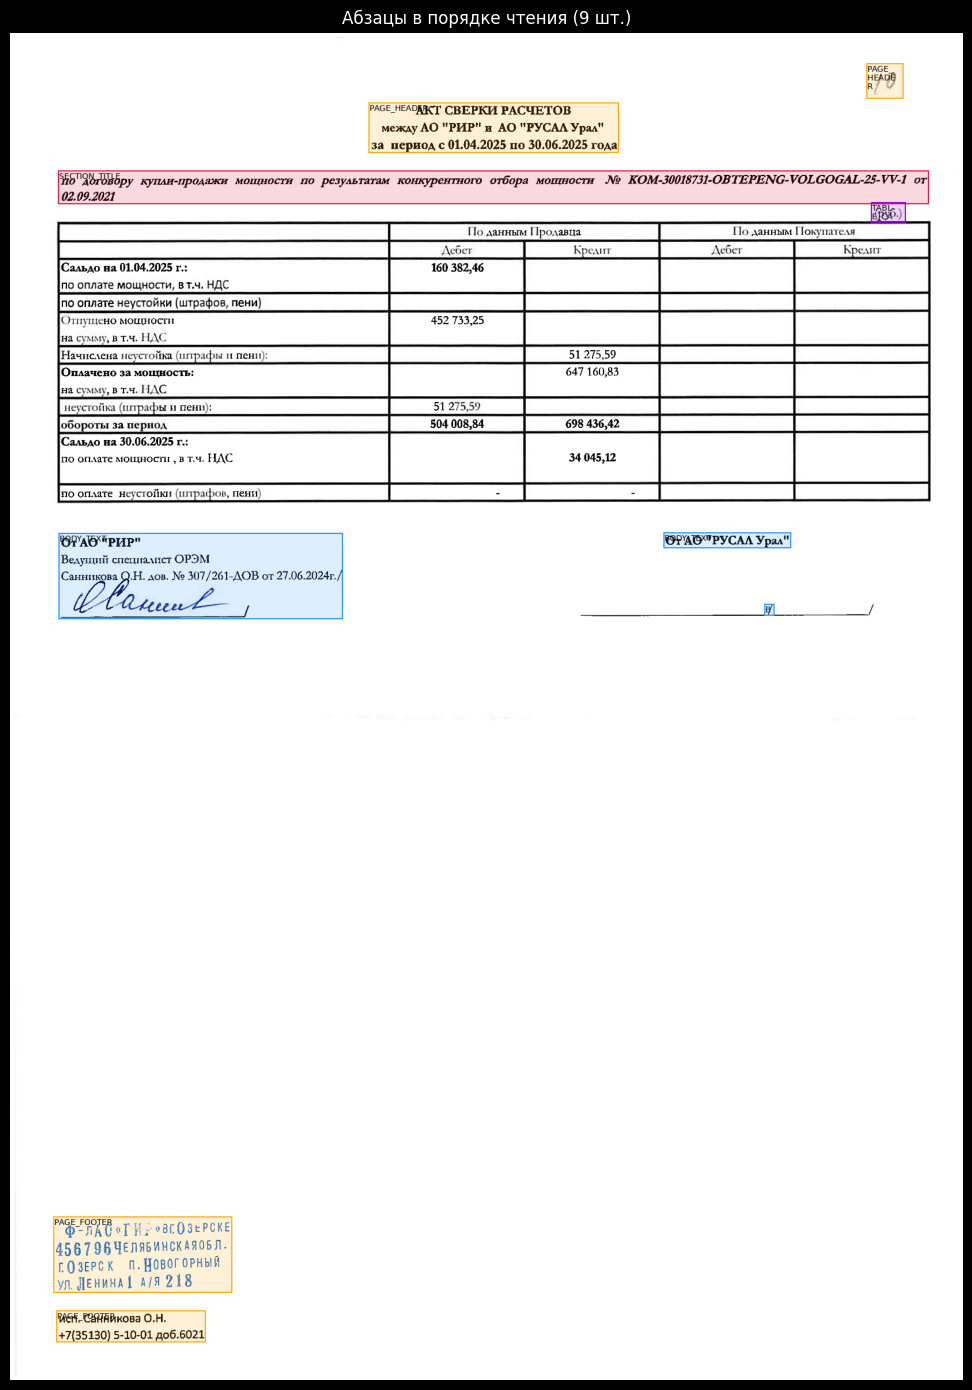

[viz] Сохранено: ../examples/output/10/paragraph_final/page_000.png


In [56]:
import matplotlib.pyplot as plt

from vision_core.utils.drawer import Drawer

TYPE_COLORS = {
    ParagraphType.PAGE_HEADER:   (255, 165,   0),  # orange
    ParagraphType.PAGE_FOOTER:   (255, 165,   0),  # orange
    ParagraphType.SECTION_TITLE: (220,  20,  60),  # crimson
    ParagraphType.TABLE_CAPTION: (148,   0, 211),  # purple
    ParagraphType.BODY_TEXT:     ( 30, 144, 255),  # blue
    ParagraphType.UNKNOWN:       (128, 128, 128),  # gray
}

drawer = Drawer(image_aligned)
for p in ordered_paragraphs:
    color = TYPE_COLORS[p.type]
    drawer.draw_structure(p.bbox.to_tuple(), color=color, width=2, fill=(*color, 40))
    drawer.draw_text_in_bbox(p.bbox.to_tuple(), text=p.type.name)

debug_final_path = f"{output_dir}/paragraph_final/page_000.png"
drawer.save(debug_final_path)

result_img = plt.imread(debug_final_path)
plt.figure(figsize=(10, 14))
plt.imshow(result_img)
plt.title(f"Абзацы в порядке чтения ({len(ordered_paragraphs)} шт.)")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"[viz] Сохранено: {debug_final_path}")
